In [1]:
import random
import pandas as pd
import numpy as np
import os
import IPython.display as ipd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import platform
import xgboost as xgb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit

import warnings
warnings.filterwarnings(action='ignore') 

In [2]:
print(f"- OS: {platform.system()} {platform.release()}")
print(f"- Python Version: {sys.version.split()[0]}")
print(f"- Pandas Version: {pd.__version__}")
print(f"- XGBoost Version: {xgb.__version__}")

- OS: Windows 10
- Python Version: 3.10.19
- Pandas Version: 2.3.3
- XGBoost Version: 3.2.0


In [3]:
# 윈도우 기본 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호(-) 깨짐 방지
plt.rc('axes', unicode_minus=False)

# 그래프 선명하게 설정 (선택 사항)
%config InlineBackend.figure_format = 'retina'

In [4]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [5]:
train.shape, test.shape

((204000, 10), (16800, 7))

In [6]:
train.isnull().sum()

num_date_time         0
건물번호                  0
일시                    0
기온(C)                 0
강수량(mm)          160069
풍속(m/s)              19
습도(%)                 9
일조(hr)            75182
일사(MJ/m2)         87913
전력소비량(kWh)            0
dtype: int64

In [7]:
test.isnull().sum()

num_date_time    0
건물번호             0
일시               0
기온(C)            0
강수량(mm)          0
풍속(m/s)          0
습도(%)            0
dtype: int64

In [8]:
train # train.head() + train.tail() 역할
# 20220601~20220824, 건물번호 1~100, 강수량과 일조+일사의 Nan 확인, 전력소비량(target)
# 단, 중복이나 중간에 비어있는 건 확인 할 수 없음

,num_date_time,건물번호,일시,기온(C),강수량(mm),풍속(m/s),습도(%),일조(hr),일사(MJ/m2),전력소비량(kWh)
0,1_20220601 00,1,20220601 00,18.6,NaN,0.9,42.0,NaN,NaN,1085.28
1,1_20220601 01,1,20220601 01,18.0,NaN,1.1,45.0,NaN,NaN,1047.36
2,1_20220601 02,1,20220601 02,17.7,NaN,1.5,45.0,NaN,NaN,974.88
3,1_20220601 03,1,20220601 03,16.7,NaN,1.4,48.0,NaN,NaN,953.76
4,1_20220601 04,1,20220601 04,18.4,NaN,2.8,43.0,NaN,NaN,986.40
...,...,...,...,...,...,...,...,...,...,...
203995,100_20220824 19,100,20220824 19,23.1,NaN,0.9,86.0,0.5,NaN,881.04
203996,100_20220824 20,100,20220824 20,22.4,NaN,1.3,86.0,0.0,NaN,798.96
203997,100_20220824 21,100,20220824 21,21.3,NaN,1.0,92.0,NaN,NaN,825.12
203998,100_20220824 22,100,20220824 22,21.0,NaN,0.3,94.0,NaN,NaN,640.08


In [9]:
test

,num_date_time,건물번호,일시,기온(C),강수량(mm),풍속(m/s),습도(%)
0,1_20220825 00,1,20220825 00,23.5,0.0,2.2,72
1,1_20220825 01,1,20220825 01,23.0,0.0,0.9,72
2,1_20220825 02,1,20220825 02,22.7,0.0,1.5,75
3,1_20220825 03,1,20220825 03,22.1,0.0,1.3,78
4,1_20220825 04,1,20220825 04,21.8,0.0,1.0,77
...,...,...,...,...,...,...,...
16795,100_20220831 19,100,20220831 19,22.5,0.0,0.9,84
16796,100_20220831 20,100,20220831 20,20.7,0.0,0.4,95
16797,100_20220831 21,100,20220831 21,20.2,0.0,0.4,98
16798,100_20220831 22,100,20220831 22,20.1,0.0,1.1,97


# 비가 정말 오긴 왔는가

In [10]:
# 강수량이 결측치(NaN)인 데이터들의 평균 습도 확인
print(train[train['강수량(mm)'].isnull()]['습도(%)'].mean())

75.97395351743096


In [11]:
# 1. 습도가 90% 이상이면서 강수량이 NaN인 데이터 추출
suspicious_rain = train[(train['습도(%)'] >= 90) & (train['강수량(mm)'].isnull())]

print(f"🧐 의심스러운 구간 데이터 수: {len(suspicious_rain)}")
print("-" * 30)
# 어떤 건물, 어떤 시간대에 이런 현상이 많은지 상위 5개만 확인
print(suspicious_rain[['건물번호', '일시', '기온(C)', '습도(%)', '강수량(mm)']].head())

🧐 의심스러운 구간 데이터 수: 31488
------------------------------
     건물번호           일시  기온(C)  습도(%)  강수량(mm)
222     1  20220610 06   17.3   91.0      NaN
294     1  20220613 06   19.6   91.0      NaN
295     1  20220613 07   20.0   92.0      NaN
364     1  20220616 04   17.9   94.0      NaN
365     1  20220616 05   17.9   95.0      NaN


In [12]:
# 1. NaN을 제외한 실제 기록된 숫자들의 빈도 확인 (상위 20개)
print("📊 강수량 기록값 상위 20개 빈도:")
print(train['강수량(mm)'].value_counts().head(20))

# 2. 0.0mm라고 '명시적으로' 기록된 데이터 개수 확인
zero_count = len(train[train['강수량(mm)'] == 0])
nan_count = train['강수량(mm)'].isnull().sum()

print(f"\n✅ 0.0mm라고 직접 기록된 경우: {zero_count}건")
print(f"⚪ 결측치(NaN)로 남겨진 경우: {nan_count}건")

📊 강수량 기록값 상위 20개 빈도:
강수량(mm)
0.0    19101
0.1     2996
0.2     1962
0.3     1431
0.4     1272
0.5     1125
0.7      783
0.8      776
0.6      715
0.9      644
1.0      630
1.3      587
1.2      556
1.1      481
1.4      438
3.0      329
1.6      318
1.7      297
1.5      270
1.9      255
Name: count, dtype: int64

✅ 0.0mm라고 직접 기록된 경우: 19101건
⚪ 결측치(NaN)로 남겨진 경우: 160069건


In [13]:
# 바로 아래 셀에서 필요하니 만듬
for data in [train, test]:
    data['일시'] = pd.to_datetime(data['일시'])
    data['year'] = data['일시'].dt.year
    data['month'] = data['일시'].dt.month
    data['day'] = data['일시'].dt.day
    data['hour'] = data['일시'].dt.hour
    data['dayofweek'] = data['일시'].dt.dayofweek

In [14]:
# 1. 시간대별 결측치 합계 확인 (이걸 보면 밤에 집중된 걸 알 수 있습니다)
null_by_hour = train[train['일조(hr)'].isnull()].groupby('hour').size()
print("⏰ 시간대별 일조량 결측치 분포:")
print(null_by_hour)

# 2. 일조/일사가 NaN인 데이터의 '기온'과 '습도' 평균 확인
print("\n☀️ 일조량이 NaN인 구간의 기상 특징:")
print(train[train['일조(hr)'].isnull()][['기온(C)', '습도(%)']].mean())

⏰ 시간대별 일조량 결측치 분포:
hour
0     8330
1     8330
2     8330
3     8330
4     8330
5     8330
6       65
7       19
8       19
9       17
10      16
11       2
12       2
13      30
14      30
15       1
16       1
17       3
18       4
19       1
20       2
21    8330
22    8330
23    8330
dtype: int64

☀️ 일조량이 NaN인 구간의 기상 특징:
기온(C)    23.901442
습도(%)    85.291936
dtype: float64


결측치 처리 -> 강수량, 일사,일조량은 = 0 <br>
강수량: 비가 오면 ?.?, 비가 안오면 0인데 0으로 잡힌 게 1만9천인데 비해 Nan값이 16만 개로 너무 많음 <br>
일사, 일조량: 0~5, 21~23에 자연스럽게 0으로 잡힘. <br>
3번째 아래 셀에서 결측치 처리 확인 가능 <br>

In [15]:
# 건물마다 전력을 쓰는 체급과 성격이 완전히 다르다는 걸 모델에게 가르쳐주기 위해서 사용한 코드
# 1. 건물 정보 데이터 로드
building_info = pd.read_csv('building_info.csv')
# 2. '건물번호'를 기준으로 train과 test 데이터에 건물 정보 병합
train = pd.merge(train, building_info, on='건물번호', how='left')
test = pd.merge(test, building_info, on='건물번호', how='left')

In [16]:
train # 제대로 병합 되었는지 확인

,num_date_time,건물번호,일시,기온(C),강수량(mm),풍속(m/s),습도(%),일조(hr),일사(MJ/m2),전력소비량(kWh),...,month,day,hour,dayofweek,건물유형,연면적(m2),냉방면적(m2),태양광용량(kW),ESS저장용량(kWh),PCS용량(kW)
0,1_20220601 00,1,2022-06-01 00:00:00,18.6,NaN,0.9,42.0,NaN,NaN,1085.28,...,6,1,0,2,건물기타,110634.00,39570.00,-,-,-
1,1_20220601 01,1,2022-06-01 01:00:00,18.0,NaN,1.1,45.0,NaN,NaN,1047.36,...,6,1,1,2,건물기타,110634.00,39570.00,-,-,-
2,1_20220601 02,1,2022-06-01 02:00:00,17.7,NaN,1.5,45.0,NaN,NaN,974.88,...,6,1,2,2,건물기타,110634.00,39570.00,-,-,-
3,1_20220601 03,1,2022-06-01 03:00:00,16.7,NaN,1.4,48.0,NaN,NaN,953.76,...,6,1,3,2,건물기타,110634.00,39570.00,-,-,-
4,1_20220601 04,1,2022-06-01 04:00:00,18.4,NaN,2.8,43.0,NaN,NaN,986.40,...,6,1,4,2,건물기타,110634.00,39570.00,-,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203995,100_20220824 19,100,2022-08-24 19:00:00,23.1,NaN,0.9,86.0,0.5,NaN,881.04,...,8,24,19,2,호텔및리조트,57497.84,40035.23,-,-,-
203996,100_20220824 20,100,2022-08-24 20:00:00,22.4,NaN,1.3,86.0,0.0,NaN,798.96,...,8,24,20,2,호텔및리조트,57497.84,40035.23,-,-,-
203997,100_20220824 21,100,2022-08-24 21:00:00,21.3,NaN,1.0,92.0,NaN,NaN,825.12,...,8,24,21,2,호텔및리조트,57497.84,40035.23,-,-,-
203998,100_20220824 22,100,2022-08-24 22:00:00,21.0,NaN,0.3,94.0,NaN,NaN,640.08,...,8,24,22,2,호텔및리조트,57497.84,40035.23,-,-,-


In [17]:
test #

,num_date_time,건물번호,일시,기온(C),강수량(mm),풍속(m/s),습도(%),year,month,day,hour,dayofweek,건물유형,연면적(m2),냉방면적(m2),태양광용량(kW),ESS저장용량(kWh),PCS용량(kW)
0,1_20220825 00,1,2022-08-25 00:00:00,23.5,0.0,2.2,72,2022,8,25,0,3,건물기타,110634.00,39570.00,-,-,-
1,1_20220825 01,1,2022-08-25 01:00:00,23.0,0.0,0.9,72,2022,8,25,1,3,건물기타,110634.00,39570.00,-,-,-
2,1_20220825 02,1,2022-08-25 02:00:00,22.7,0.0,1.5,75,2022,8,25,2,3,건물기타,110634.00,39570.00,-,-,-
3,1_20220825 03,1,2022-08-25 03:00:00,22.1,0.0,1.3,78,2022,8,25,3,3,건물기타,110634.00,39570.00,-,-,-
4,1_20220825 04,1,2022-08-25 04:00:00,21.8,0.0,1.0,77,2022,8,25,4,3,건물기타,110634.00,39570.00,-,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16795,100_20220831 19,100,2022-08-31 19:00:00,22.5,0.0,0.9,84,2022,8,31,19,2,호텔및리조트,57497.84,40035.23,-,-,-
16796,100_20220831 20,100,2022-08-31 20:00:00,20.7,0.0,0.4,95,2022,8,31,20,2,호텔및리조트,57497.84,40035.23,-,-,-
16797,100_20220831 21,100,2022-08-31 21:00:00,20.2,0.0,0.4,98,2022,8,31,21,2,호텔및리조트,57497.84,40035.23,-,-,-
16798,100_20220831 22,100,2022-08-31 22:00:00,20.1,0.0,1.1,97,2022,8,31,22,2,호텔및리조트,57497.84,40035.23,-,-,-


In [18]:
# XGBoost 모델이 '문자'를 이해할 수 있도록 번역해주고, 동시에 모델의 성능을 효율적으로 끌어올리기 위해 사용
categorical_cols = train.select_dtypes(include=['object']).columns
for col in categorical_cols:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')
# fit 바로 위에 enable_categorical=True 있음 -> 데이터프레임에서 astype('category')로 설정한 컬럼들을 모델이 인식 시킴

In [19]:
# 3번째 윗 셀에서 이 코드를 사용한 이유 확인 가능 -> 데이터 왜곡 방지
# 1. 처리할 컬럼 리스트
zero_cols = ['강수량(mm)', '일조(hr)', '일사(MJ/m2)']

# 2. Train 데이터 처리
for col in zero_cols:
    train[col] = train[col].fillna(0)

# 3. Test 데이터 처리 (없으면 생성, 있으면 결측치 채우기)
for col in zero_cols:
    if col not in test.columns:
        # 컬럼이 아예 없으면 0으로 가득 채운 새 컬럼 생성
        test[col] = 0
    else:
        # 컬럼이 있다면 결측치만 0으로 채움
        test[col] = test[col].fillna(0)

# 4. 선형 보간 (기온, 풍속, 습도)
cols_to_interp = ['기온(C)', '풍속(m/s)', '습도(%)']
train[cols_to_interp] = train[cols_to_interp].interpolate(method='linear')
test[cols_to_interp] = test[cols_to_interp].interpolate(method='linear')
# interpolate(method='linear')는 비어있는 칸을 앞뒤 숫자의 평균값으로 부드럽게 이어주는 역할
# 결과 확인
print(train.isnull().sum())
print(test.isnull().sum())

num_date_time    0
건물번호             0
일시               0
기온(C)            0
강수량(mm)          0
풍속(m/s)          0
습도(%)            0
일조(hr)           0
일사(MJ/m2)        0
전력소비량(kWh)       0
year             0
month            0
day              0
hour             0
dayofweek        0
건물유형             0
연면적(m2)          0
냉방면적(m2)         0
태양광용량(kW)        0
ESS저장용량(kWh)     0
PCS용량(kW)        0
dtype: int64
num_date_time    0
건물번호             0
일시               0
기온(C)            0
강수량(mm)          0
풍속(m/s)          0
습도(%)            0
year             0
month            0
day              0
hour             0
dayofweek        0
건물유형             0
연면적(m2)          0
냉방면적(m2)         0
태양광용량(kW)        0
ESS저장용량(kWh)     0
PCS용량(kW)        0
일조(hr)           0
일사(MJ/m2)        0
dtype: int64


In [20]:
#for data in [train, test]:
#    data['일시'] = pd.to_datetime(data['일시'])
#    data['year'] = data['일시'].dt.year
#    data['month'] = data['일시'].dt.month
#    data['day'] = data['일시'].dt.day
#    data['hour'] = data['일시'].dt.hour
#    data['dayofweek'] = data['일시'].dt.dayofweek

In [21]:
# =========================================================================
# [추가] team_ex10: 임시 휴무일 통계적 Drop 로직
# =========================================================================
print(f"🧹 임시 휴무 Drop 전 Train 크기: {train.shape}")

# 1. 계산을 위해 date 컬럼 임시 생성
train['date'] = train['일시'].dt.date

# 2. 건물별 + 일별 '총 전력소비량' 계산
daily_power = train.groupby(['건물번호', 'date'])['전력소비량(kWh)'].sum().reset_index()
daily_power.rename(columns={'전력소비량(kWh)': '일별총전력'}, inplace=True)

# 3. 건물별 하루 전력소비량의 '중앙값(평소 전력량)' 계산 (평균보다 이상치에 강함)
building_median = daily_power.groupby('건물번호')['일별총전력'].median().reset_index()
building_median.rename(columns={'일별총전력': '건물평소전력'}, inplace=True)

# 4. 데이터 병합 및 비율 계산
daily_power = pd.merge(daily_power, building_median, on='건물번호')
daily_power['전력비율'] = daily_power['일별총전력'] / daily_power['건물평소전력'] # 건물의 크기와 상관없이 상대적인 사용량을 확인

# 5. Drop 기준: 평소 전력량의 30% (0.3) 이하만 쓴 날을 '휴무'로 간주 -> 필수 기기만 돌아간 증거
# (이 0.3 이라는 수치는 실험을 통해 0.2 나 0.4 로 조절 가능합니다)
closed_days = daily_power[daily_power['전력비율'] < 0.3][['건물번호', 'date']]
closed_days['is_closed'] = 1

# 6. 원본 train 데이터에 휴무일 정보 매핑
train = pd.merge(train, closed_days, on=['건물번호', 'date'], how='left')
train['is_closed'] = train['is_closed'].fillna(0)

# 7. 휴무일(1)인 행을 Drop 하고 정상(0)인 행만 남김
train = train[train['is_closed'] == 0].reset_index(drop=True)

# 8. 임시로 만든 컬럼들 청소
train.drop(columns=['is_closed', 'date'], inplace=True)

print(f"✨ 임시 휴무 Drop 후 Train 크기: {train.shape}")
# =========================================================================

🧹 임시 휴무 Drop 전 Train 크기: (204000, 21)
✨ 임시 휴무 Drop 후 Train 크기: (203904, 21)


In [22]:
print(train['건물유형'].nunique())

12


In [23]:
# 건물유형별 데이터 개수 확인 (어떤 유형이 가장 많은지)
print("🏢 건물유형별 데이터 분포:")
print(train['건물유형'].value_counts())

🏢 건물유형별 데이터 분포:
건물유형
건물기타       30600
공공         16320
대학교        16320
병원         16320
호텔및리조트     16320
상용         16320
아파트        16320
지식산업센터     16320
할인마트       16296
연구소        16296
백화점및아울렛    16272
데이터센터      10200
Name: count, dtype: int64


In [24]:
# 건물유형별 전력소비량 평균/중앙값 확인
type_stats = train.groupby('건물유형')['전력소비량(kWh)'].agg(['mean', 'median', 'max', 'std']).sort_values(by='mean', ascending=False)
print("\n📊 건물유형별 전력소비 통계:")
print(type_stats)


📊 건물유형별 전력소비 통계:
                mean   median       max          std
건물유형                                                
대학교      5458.636005  2691.54  25488.40  5780.781533
데이터센터    5396.897682  3371.40  10272.24  3220.339049
병원       2912.790081  2693.10   7808.16  1210.082439
연구소      2811.064945  2479.32   7193.52  1629.373081
상용       2299.375129  2392.20   4943.52  1251.657276
백화점및아울렛  2269.023164  1969.14   6439.80  1662.765147
건물기타     1971.725375  1732.08   7694.64  1056.020914
지식산업센터   1935.542445  1583.34   6788.88  1151.798530
공공       1683.978456  1307.32   5350.08  1051.547289
호텔및리조트   1480.069184  1273.14   4379.76   817.322294
할인마트     1417.355140  1558.80   3171.12   735.989205
아파트      1309.000627  1056.87   6038.28   952.192148


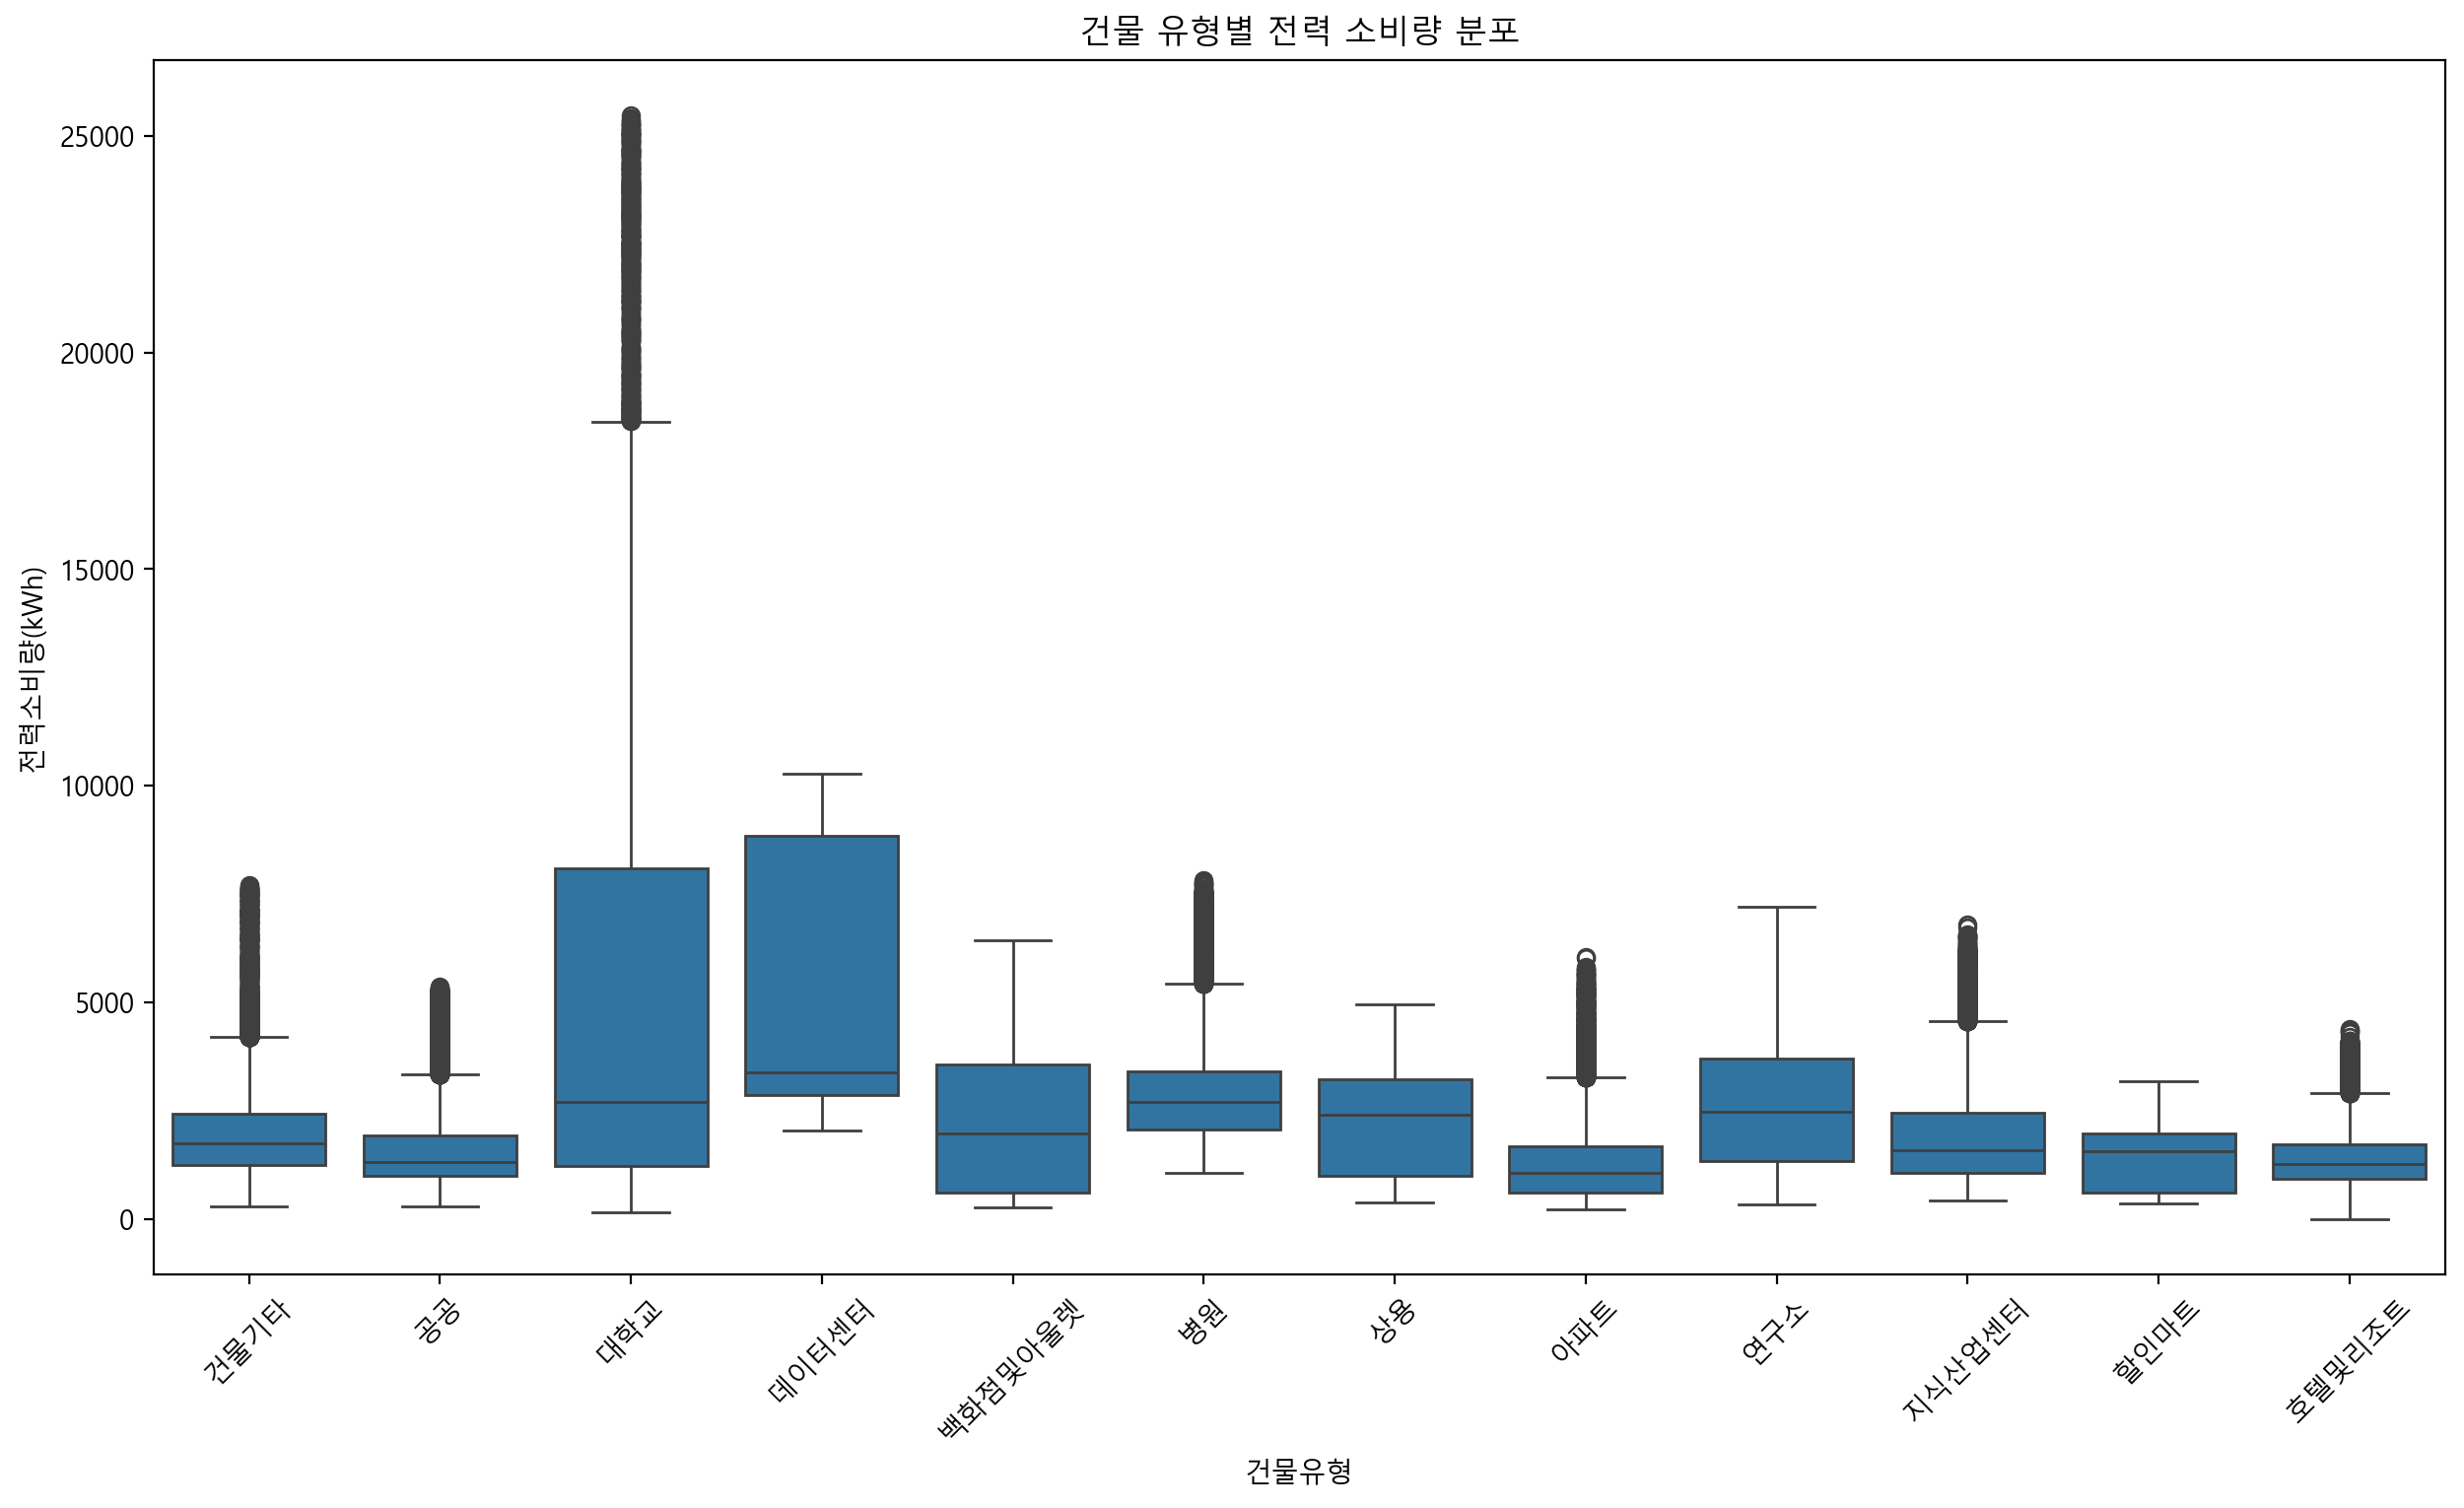

In [25]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=train, x='건물유형', y='전력소비량(kWh)')
plt.xticks(rotation=45) # 글자가 겹치지 않게 회전
plt.title('건물 유형별 전력 소비량 분포')
plt.show()

In [26]:
# 이 코드는 시간의 연속성(Cycle)을 모델에게 가르쳐주기 위해 사용
train['hour_sin'] = np.sin(2*np.pi*train['hour']/24)
train['hour_cos'] = np.cos(2*np.pi*train['hour']/24)

test['hour_sin'] = np.sin(2*np.pi*test['hour']/24)
test['hour_cos'] = np.cos(2*np.pi*test['hour']/24)

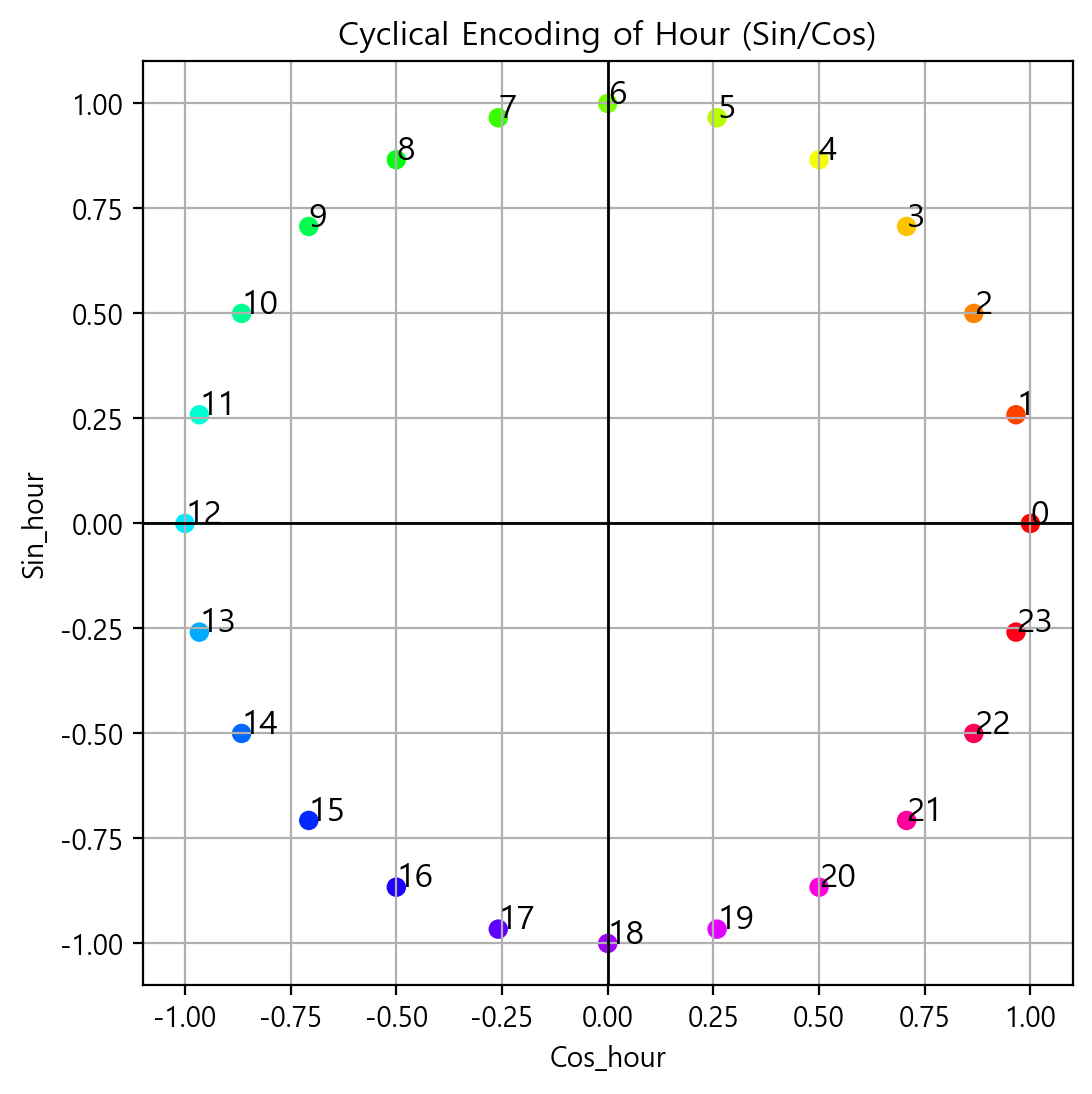

In [27]:
# 0시부터 23시까지 데이터 생성 -> 23시와 0시가 붙어있는 걸 확인 시켜줌
hours = np.arange(24)
sin_time = np.sin(2 * np.pi * hours / 24)
cos_time = np.cos(2 * np.pi * hours / 24)

plt.figure(figsize=(6, 6))
plt.scatter(cos_time, sin_time, c=hours, cmap='hsv') # 시간에 따라 색상 부여

# 각 점에 시간 표시
for i, txt in enumerate(hours):
    plt.annotate(txt, (cos_time[i], sin_time[i]), fontsize=12)

plt.title("Cyclical Encoding of Hour (Sin/Cos)")
plt.xlabel("Cos_hour")
plt.ylabel("Sin_hour")
plt.grid(True)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.show()

In [28]:
# 6월 6일 평균 대비 6월 7일 평균 전력의 비율 계산
#june_6 = train[train['일시'].dt.strftime('%m-%d') == '06-06'].groupby('건물번호')['전력소비량(kWh)'].mean()
#june_7 = train[train['일시'].dt.strftime('%m-%d') == '06-07'].groupby('건물번호')['전력소비량(kWh)'].mean()

#drop_ratio = (june_6 / june_7)
# 비율이 0.7 미만(30% 이상 급감)인 건물들만 보기
#sensitive_buildings = drop_ratio[drop_ratio < 0.7].index.tolist()

#print(f"공휴일에 민감한 건물 번호: {sensitive_buildings}")

In [29]:
# 06-01(2022년 지방선거일), 06-06(현충일), 08-15(광복절) 
train['is_holiday'] = train['일시'].dt.strftime('%m-%d').isin(['06-01', '06-06', '08-15']).astype(int)
train['is_holiday'] = ((train['is_holiday'] == 1) | (train['dayofweek'] >= 5)).astype(int)
# 토요일(5)과 일요일(6)은 매주 반복되는 '정기 휴일' -> 공휴일과 주말을 하나의 is_holiday 피처로

위의 홀리데이, 아래의 위캔으로 피쳐 중첩 시킨 걸 모델에게 학습
일반 평일: is_holiday=0, is_weekend=0

공휴일(평일): is_holiday=1, is_weekend=0

주말: is_holiday=1, is_weekend=1

In [30]:
# 모델에게 주말, 공휴일 구분할 단서 제공, 5와 6이 묶음인 것 인식 시킴
train['is_weekend'] = (train['dayofweek'] >= 5).astype(int)
test['is_weekend'] = (test['dayofweek'] >= 5).astype(int)

In [31]:
# 데이터가 여름철 6~8월 데이터라 같은 온도여도 습도가 다르면 체감되는 게 다름
# 바로 아래 셀에서 확인 가능
# 불쾌지수 계산 함수 정의
def calculate_di(temp, humid):
    return 1.8 * temp - 0.55 * (1 - humid/100) * (1.8 * temp - 26) + 32

# 피처 생성
train['DI'] = calculate_di(train['기온(C)'], train['습도(%)'])
test['DI'] = calculate_di(test['기온(C)'], test['습도(%)'])

# 확인용
print(train[['기온(C)', '습도(%)', 'DI']].head())

   기온(C)  습도(%)        DI
0   18.6   42.0  63.09388
1   18.0   45.0  62.46400
2   17.7   45.0  62.08735
3   16.7   48.0  60.89884
4   18.4   43.0  62.88788


In [32]:
# 상관계수 계산
dist_corr = train[['기온(C)', '습도(%)', 'DI']].corr()

print("🌡️ 기온, 습도, DI 간의 상관계수:")
display(dist_corr)

🌡️ 기온, 습도, DI 간의 상관계수:


,기온(C),습도(%),DI
기온(C),1.000000,-0.390175,0.953579
습도(%),-0.390175,1.000000,-0.111233
DI,0.953579,-0.111233,1.000000


<Figure size 1000x800 with 0 Axes>

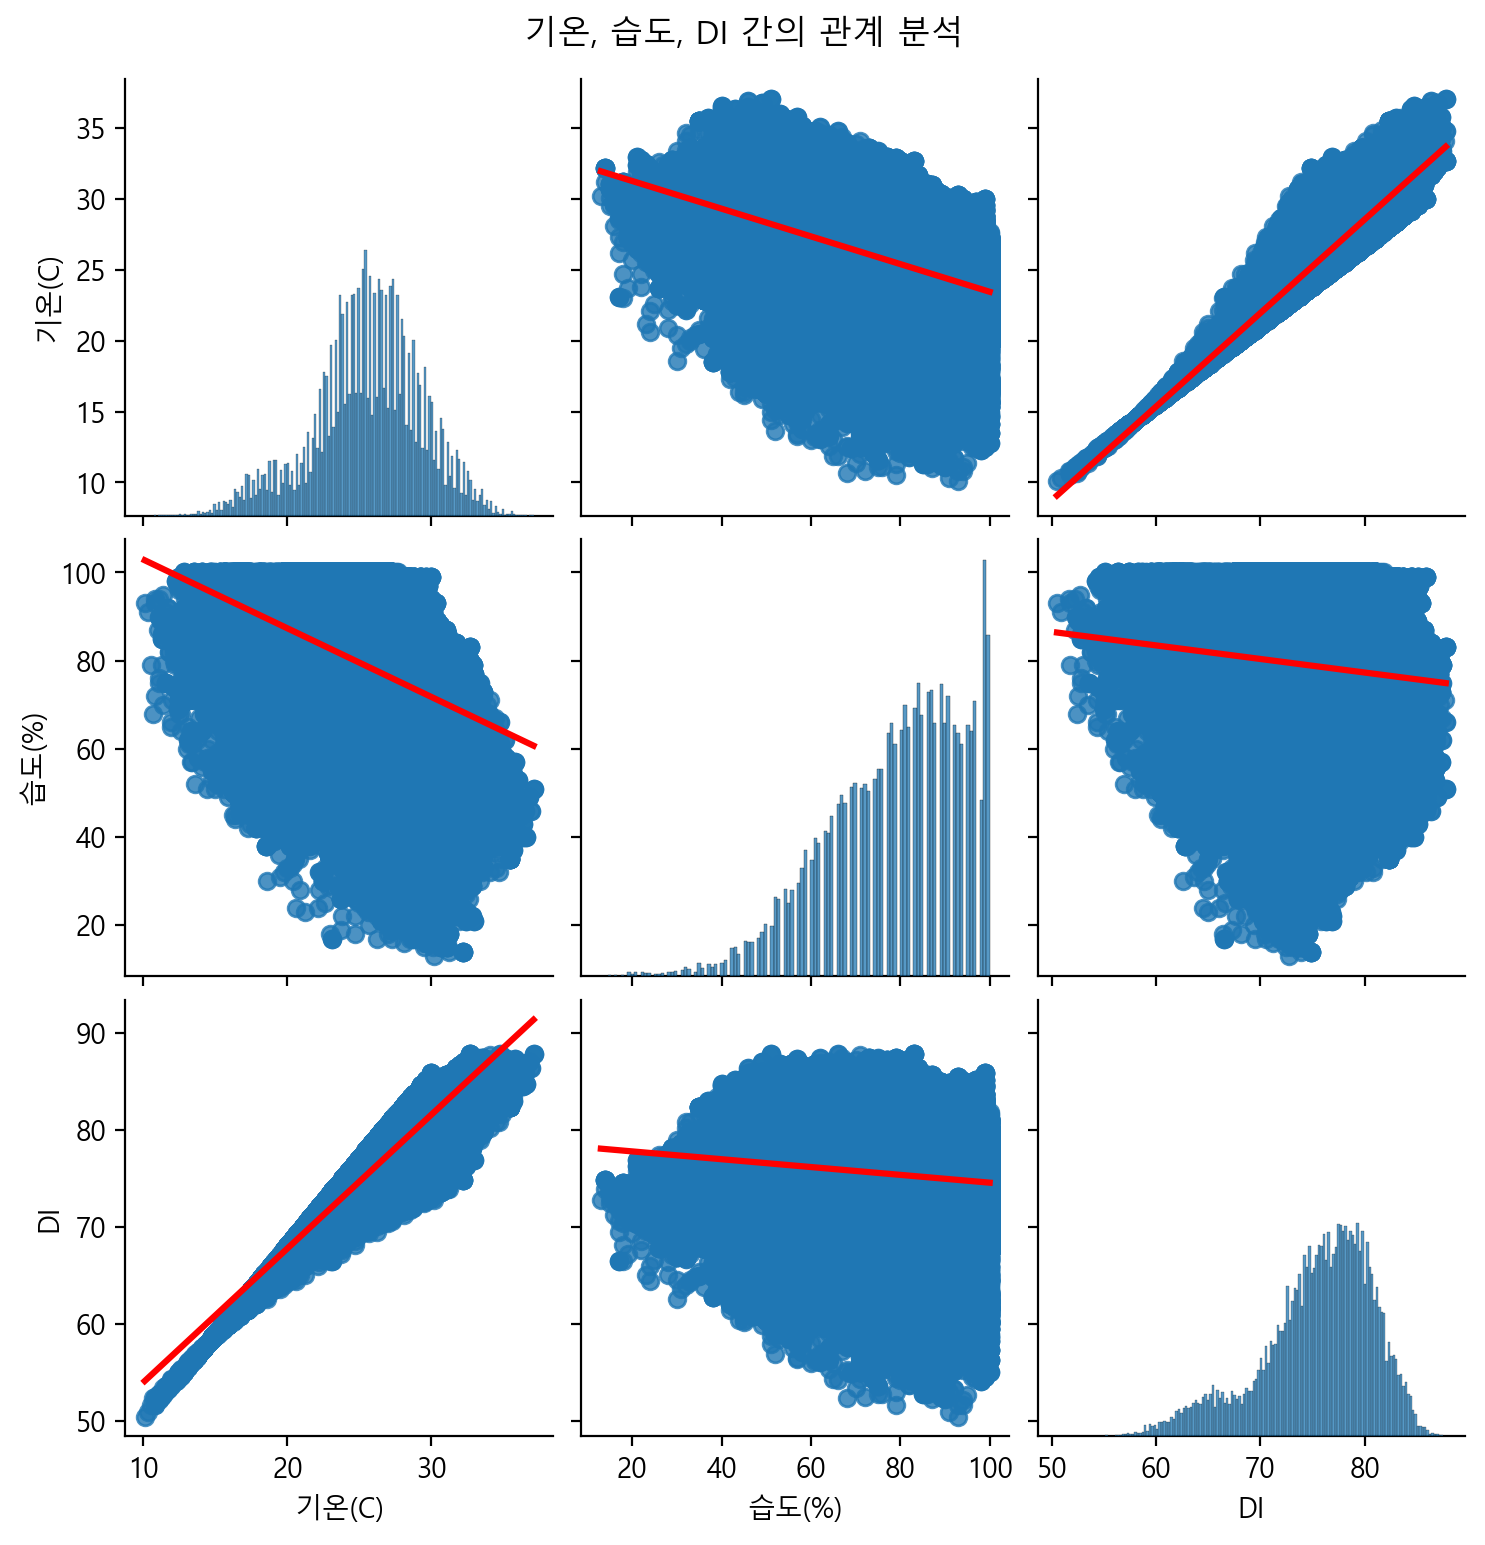

In [33]:
# 시각화 설정
plt.figure(figsize=(10, 8))
sns.pairplot(train[['기온(C)', '습도(%)', 'DI']], kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle("기온, 습도, DI 간의 관계 분석", y=1.02)
plt.show()

In [34]:
# 평균기온은 오늘의 온도를, 최대기온은 최대기온이 찍히는 시간대를 모델에게 인식 시키기 위해
for df in [train, test]:
    df['date'] = df['일시'].dt.date 

    # 건물별 + 날짜별로 그룹화하여 평균, 최대 계산
    df['평균기온'] = df.groupby(['건물번호', 'date'])['기온(C)'].transform('mean')
    df['최대기온'] = df.groupby(['건물번호', 'date'])['기온(C)'].transform('max')

    # 사용 후 date 컬럼 제거 (선택 사항)
    df.drop(columns=['date'], inplace=True)

In [35]:
# 기온, 습도, 풍속, AT(풍속+체감온도)를 모델 보고 알아서 조합해보라고
# 체감온도(Apparent Temperature) 계산 함수 정의
def calculate_at(temp, humid, wind):
    # 수증기압(e) 계산
    e = (humid / 100) * 6.105 * np.exp(17.27 * temp / (237.7 + temp))
    # 체감온도 공식 (여름철 풍속 영향 반영)
    return 1.04 * temp + 0.2 * e - 0.65 * wind - 2.7

# [기존 코드의 피처 생성 부분에 추가]
# Train 데이터
train['AT'] = calculate_at(train['기온(C)'], train['습도(%)'], train['풍속(m/s)'])

# Test 데이터
test['AT'] = calculate_at(test['기온(C)'], test['습도(%)'], test['풍속(m/s)'])

# 확인용
print(train[['기온(C)', '습도(%)', '풍속(m/s)', 'AT']].head())

   기온(C)  습도(%)  풍속(m/s)         AT
0   18.6   42.0      0.9  17.854843
1   18.0   45.0      1.1  17.158145
2   17.7   45.0      1.5  16.551526
3   16.7   48.0      1.4  15.578997
4   18.4   43.0      2.8  16.431747


In [36]:
# =========================================================================
# [추가] team_ex11: 건물별 전력 사용 패턴 기반 클러스터링 (성향 분석)
# =========================================================================

print("🧬 건물의 유전자(사용 패턴) 분석 중...")

# 1. 건물별 특징(Feature) 추출용 데이터프레임 생성
building_profiles = []

for b_num in train['건물번호'].unique():
    b_data = train[train['건물번호'] == b_num]
    
    # 성향 A: 건물 체급 (평균 사용량) # 건물이 대형인지 소형인지 확인
    mean_p = b_data['전력소비량(kWh)'].mean()
    
    # 성향 B: 냉방 민감도 (기온과 전력량의 상관관계) # 기온이 오를 때 전력량이 얼마나 민감하게 반응하는지
    temp_corr = b_data[['전력소비량(kWh)', '기온(C)']].corr().iloc[0, 1]
    
    # 성향 C: 운영 패턴 (주말/주중 전력 사용 비율) # 주말에도 전기를 쓰는지 확인
    # 0에 가까우면 주말에 완전히 쉬는 건물, 1에 가까우면 24시간 풀가동 건물
    weekday_p = b_data[b_data['dayofweek'] < 5]['전력소비량(kWh)'].mean()
    weekend_p = b_data[b_data['dayofweek'] >= 5]['전력소비량(kWh)'].mean()
    op_pattern = weekend_p / (weekday_p + 1e-6)
    
    building_profiles.append([b_num, mean_p, temp_corr, op_pattern])

df_profiles = pd.DataFrame(building_profiles, columns=['건물번호', 'mean_p', 'temp_corr', 'op_pattern'])

# 2. 클러스터링 (K-Means) 실행
# 특징들의 단위가 다르므로 스케일링 필수!
scaler = StandardScaler() # 모든 특징의 중요도를 똑같은 무게(0을 중심으로 한 표준 범위)로
features_scaled = scaler.fit_transform(df_profiles[['mean_p', 'temp_corr', 'op_pattern']])

# 4개 그룹으로 분류 # 건물유형은 12개인 것(67번셀)을 위에서 확인 했는데 왜 4개인지는 아래 셀에서 확인
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_profiles['building_cluster'] = kmeans.fit_predict(features_scaled)

# 3. 원본 데이터(train, test)에 클러스터 정보 합치기
train = pd.merge(train, df_profiles[['건물번호', 'building_cluster']], on='건물번호', how='left')
test = pd.merge(test, df_profiles[['건물번호', 'building_cluster']], on='건물번호', how='left')

# 카테고리 형으로 변환 (XGBoost가 범주형으로 인식하도록)
train['building_cluster'] = train['building_cluster'].astype('category')
test['building_cluster'] = test['building_cluster'].astype('category')

print(f"✅ 클러스터링 완료! 분류 현황:\n{df_profiles['building_cluster'].value_counts().sort_index()}")
# =========================================================================

🧬 건물의 유전자(사용 패턴) 분석 중...


Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\user\miniconda3\envs\sa\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\user\miniconda3\envs\sa\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\user\miniconda3\envs\sa\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\user\miniconda3\envs\sa\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte


✅ 클러스터링 완료! 분류 현황:
building_cluster
0    33
1    45
2     4
3    18
Name: count, dtype: int64


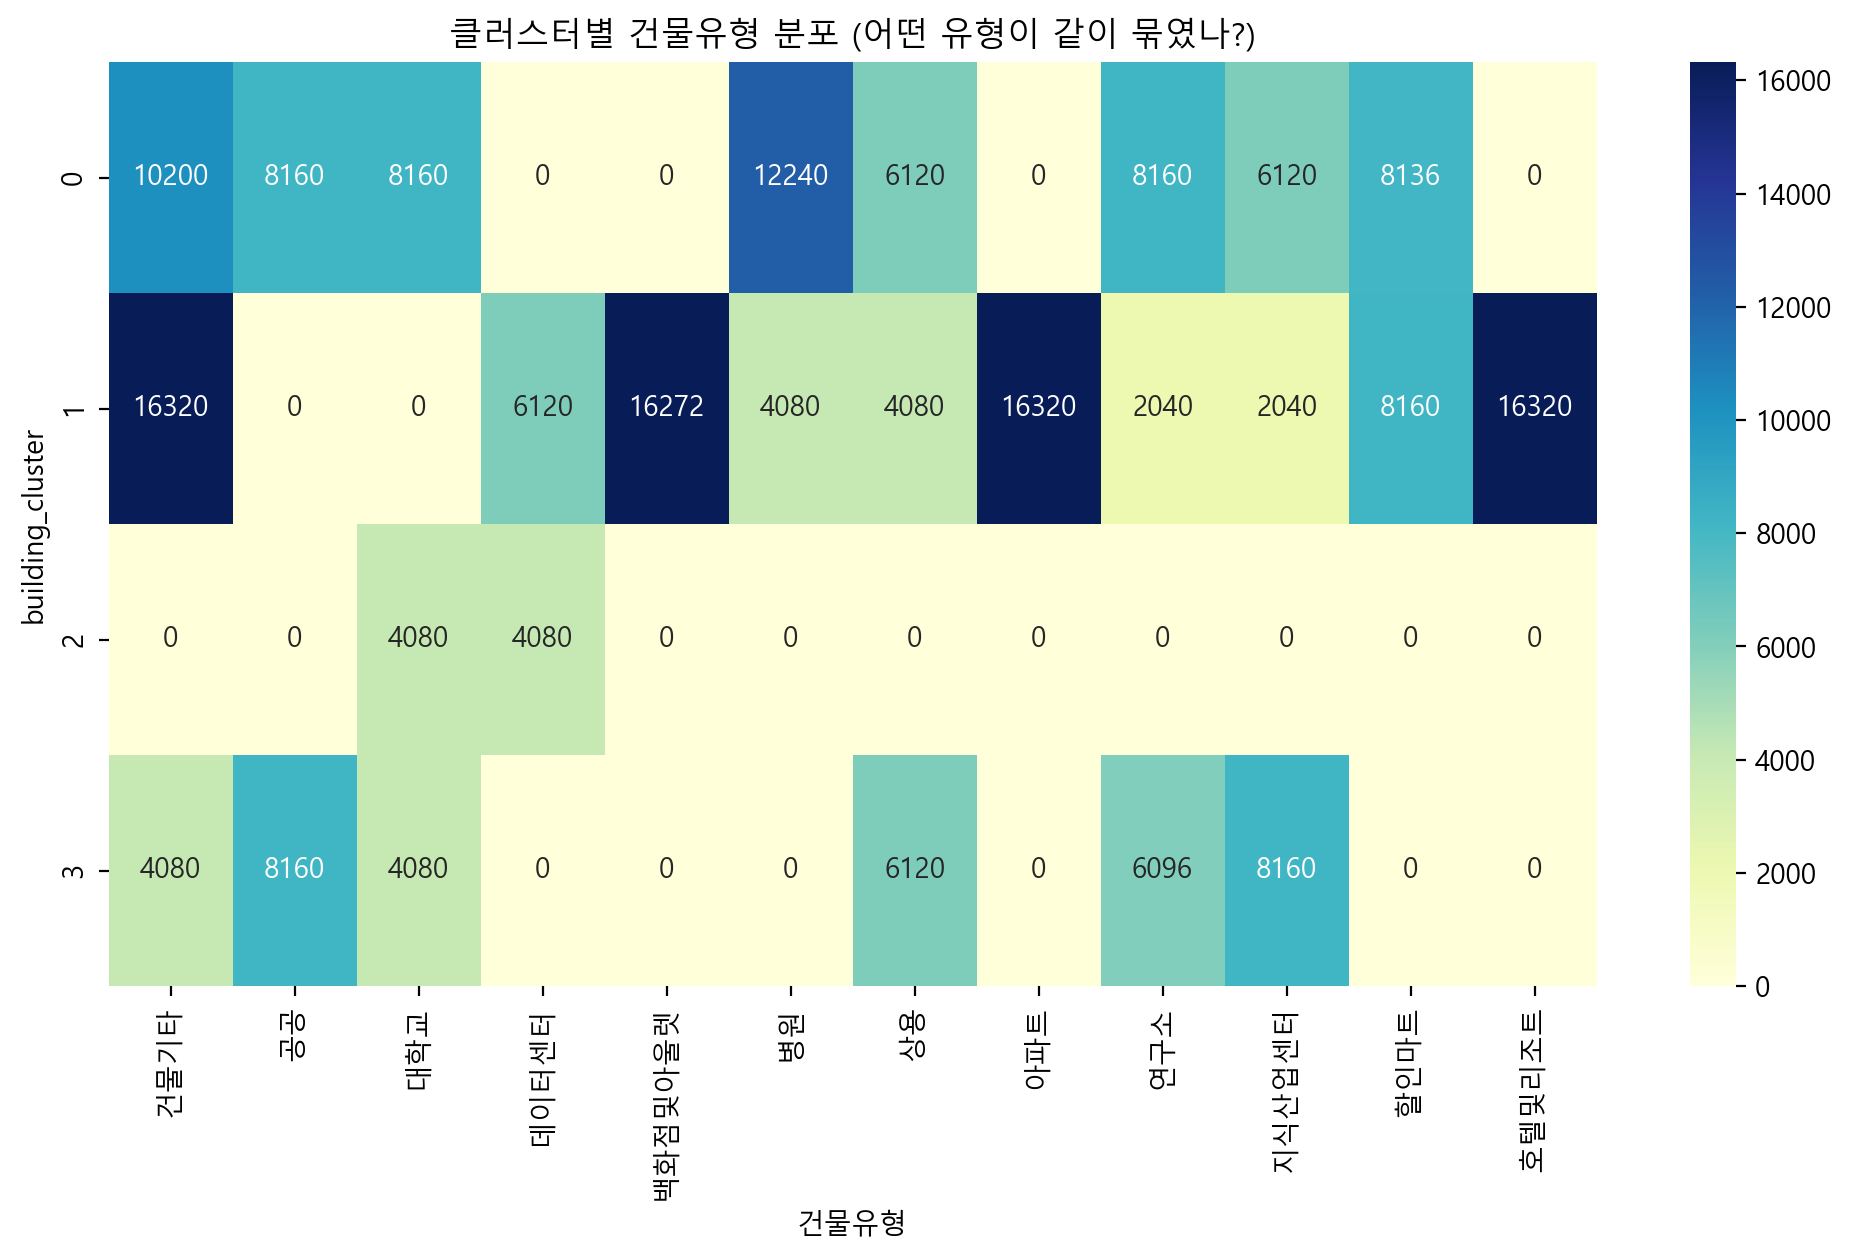

In [37]:
# 클러스터별로 어떤 건물유형들이 들어있는지 확인
cluster_type_count = train.groupby(['building_cluster', '건물유형']).size().unstack(fill_value=0)

# 한 눈에 보기 위해 히트맵으로 시각화
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_type_count, annot=True, fmt='d', cmap='YlGnBu')
plt.title('클러스터별 건물유형 분포 (어떤 유형이 같이 묶였나?)')
plt.show()

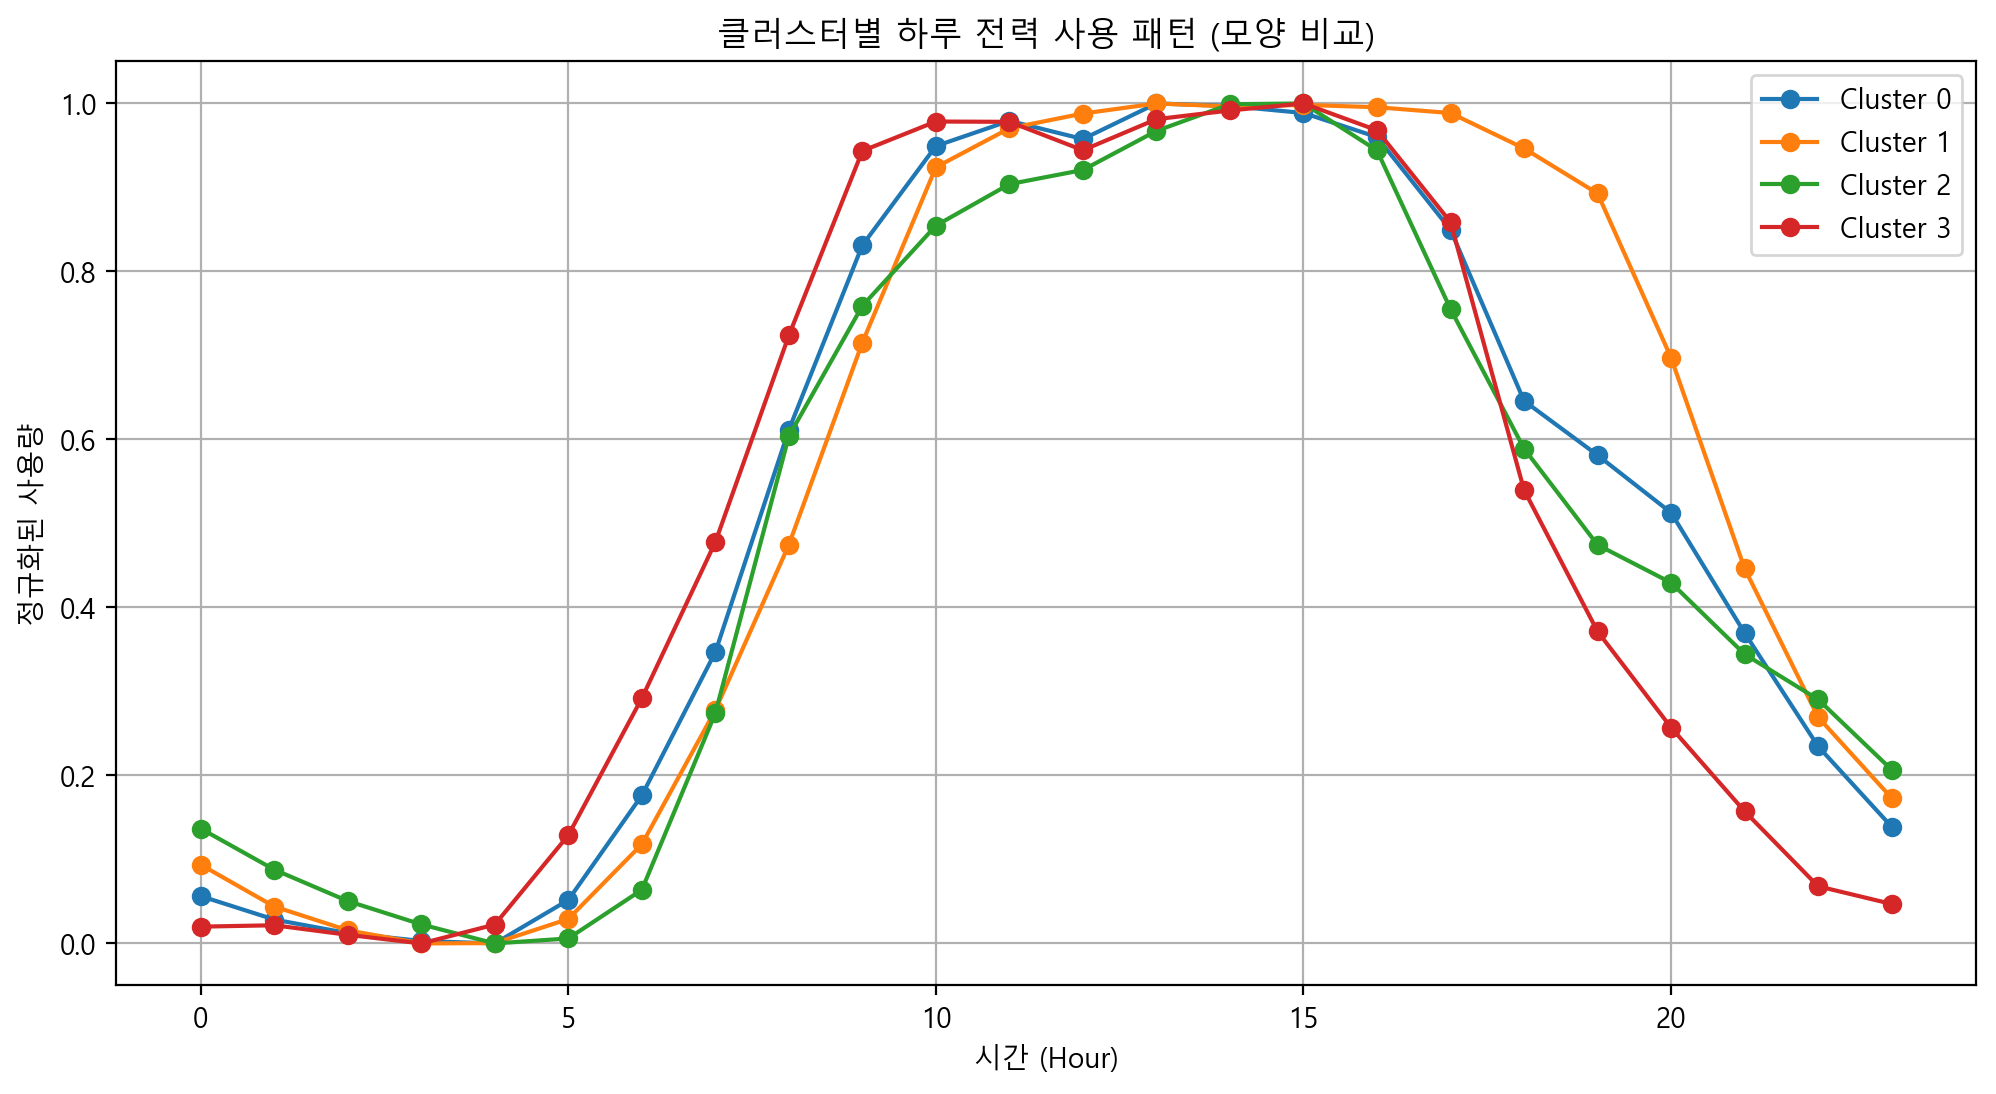

In [38]:
# 클러스터별로 시간대별 평균 전력 사용량 그리기
plt.figure(figsize=(12, 6))
for cluster_num in range(4):
    subset = train[train['building_cluster'] == cluster_num]
    # 시간대별 평균 (스케일 차이가 크므로 0~1 사이로 정규화해서 모양만 비교)
    hourly_pattern = subset.groupby('hour')['전력소비량(kWh)'].mean()
    hourly_pattern = (hourly_pattern - hourly_pattern.min()) / (hourly_pattern.max() - hourly_pattern.min())
    
    plt.plot(hourly_pattern, label=f'Cluster {cluster_num}', marker='o')

plt.title('클러스터별 하루 전력 사용 패턴 (모양 비교)')
plt.xlabel('시간 (Hour)')
plt.ylabel('정규화된 사용량')
plt.legend()
plt.grid(True)
plt.show()

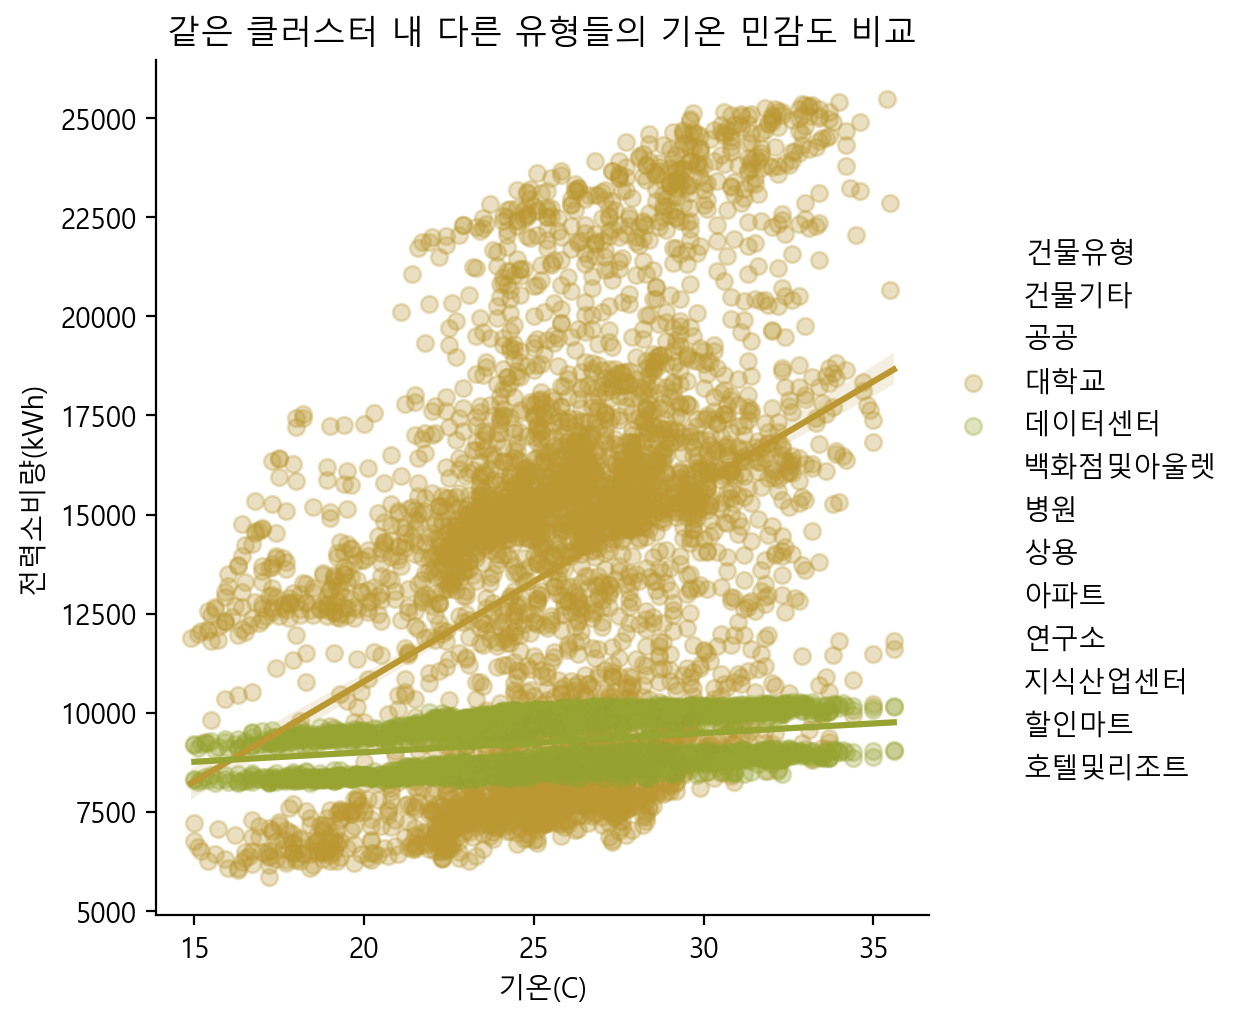

In [39]:
# 특정 클러스터 내의 서로 다른 유형 두 개를 골라 기온 대비 전력량 산점도 비교
sns.lmplot(data=train[train['building_cluster'] == 2], # 예: 2번 클러스터
           x='기온(C)', y='전력소비량(kWh)', hue='건물유형', scatter_kws={'alpha':0.3})
plt.title('같은 클러스터 내 다른 유형들의 기온 민감도 비교')
plt.show()

In [40]:
# [1] 공통 피처 리스트 정의 (순서가 중요합니다!)
features = [
    '건물번호','building_cluster', '기온(C)', '강수량(mm)', '풍속(m/s)', '습도(%)', 'DI','평균기온', '최대기온', 'AT',
    'month', 'day', 'hour', 'dayofweek', 'hour_sin', 'hour_cos', 'is_holiday','is_weekend', '건물유형', '연면적(m2)', '냉방면적(m2)', '태양광용량(kW)', 'ESS저장용량(kWh)', 'PCS용량(kW)'
]

# [2] Test 데이터 전처리 (Train은 이미 되어 있다고 가정)
test['일시'] = pd.to_datetime(test['일시'])
test['month'] = test['일시'].dt.month
test['day'] = test['일시'].dt.day
test['hour'] = test['일시'].dt.hour
test['dayofweek'] = test['일시'].dt.dayofweek

# 공휴일 생성 (현충일, 광복절 + 주말) # 06-01 선거일 
test['is_holiday'] = test['일시'].dt.strftime('%m-%d').isin(['06-01', '06-06', '08-15']).astype(int)
test['is_holiday'] = ((test['is_holiday'] == 1) | (test['dayofweek'] >= 5)).astype(int)
# DI(불쾌지수) 생성
#test['DI'] = 1.8 * test['기온(C)'] - 0.55 * (1 - test['습도(%)']/100) * (1.8 * test['기온(C)'] - 26) + 32


# 1. SMAPE 평가 지표 함수 정의
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)))

# 2. TimeSeriesSplit을 위해 데이터 정렬 (핵심!)
# 시계열 순서가 섞이지 않도록 일시 및 건물번호 기준으로 정렬합니다.
train = train.sort_values(['일시', '건물번호']).reset_index(drop=True)

X_train = train[features]
y_train = train['전력소비량(kWh)']
X_test = test[features]

print(f"✅ 데이터 준비 완료! (Train: {X_train.shape}, Test: {X_test.shape})")

# 3. TimeSeriesSplit 설정 # 시계열 교차검증
n_splits = 5 # 데이터를 5번 쪼개서(n_splits=5) 학습 -> 각기 다른 기간을 집중적으로 공부한 5개의 모델
tscv = TimeSeriesSplit(n_splits=n_splits)

# 폴드별 예측값을 누적할 배열 (OOF 앙상블)
test_preds = np.zeros(len(X_test))
val_scores = []

print("🚀 TimeSeriesSplit 교차 검증 시작...")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    # 훈련용/검증용 데이터 분할
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    # 모델 정의
    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=7,
        random_state=42,
        tree_method='hist',
        n_jobs=-1,
        enable_categorical=True
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False # 로그가 너무 길어지는 것 방지
    )
    
    # 검증 세트 예측 및 SMAPE 계산
    val_preds = model.predict(X_val)
    fold_smape = smape(y_val, val_preds)
    val_scores.append(fold_smape)
    
    print(f"Fold {fold+1} SMAPE: {fold_smape:.4f}")
    
    # 테스트 세트 예측 (각 폴드의 예측값을 평균내어 최종 예측 앙상블)
    test_preds += model.predict(X_test) / n_splits

print(f"\n✨ 교차 검증 완료! 평균 Val SMAPE: {np.mean(val_scores):.4f}")

# [6] 제출용 파일 생성
submission = pd.read_csv('sample_submission.csv') 
submission['answer'] = test_preds

# 파일 저장 (이 코드를 복사해서 쓰세요!)
submission.to_csv('team_ex12.csv', index=False)

print("🏁 제출 파일(team_ex12.csv)이 생성되었습니다!") 

✅ 데이터 준비 완료! (Train: (203904, 24), Test: (16800, 24))
🚀 TimeSeriesSplit 교차 검증 시작...
Fold 1 SMAPE: 11.9099
Fold 2 SMAPE: 13.7295
Fold 3 SMAPE: 8.1471
Fold 4 SMAPE: 8.6318
Fold 5 SMAPE: 7.5493

✨ 교차 검증 완료! 평균 Val SMAPE: 9.9935
🏁 제출 파일(team_ex12.csv)이 생성되었습니다!
